In [ ]:
# =========================================================
# MULTI-TIMEFRAME LSTM TRADING SYSTEM
# Dynamic Risk by Confidence
# 15M + 4H | ATR SL/TP | AUTO LOT | FULL METRICS
# =========================================================

!pip install -q yfinance tensorflow numpy pandas scikit-learn ta

# ================= IMPORTS =================
import yfinance as yf
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
import ta

np.random.seed(42)
tf.random.set_seed(42)

# ================= SETTINGS =================
SYMBOL = "GC=F"        # Gold Futures (XAUUSD proxy)
LOOKBACK = 60
EPOCHS = 3

ATR_MULT_SL = 1.2
ATR_MULT_TP = 2.5

DOLLAR_PER_POINT_PER_LOT = 100   # XAUUSD approx
MIN_LOT = 0.01
MAX_LOT = 5.0

# ================= DOWNLOAD DATA =================
df = yf.download(SYMBOL, period="12d", interval="15m")

# Fix Yahoo Finance MultiIndex issue
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['High','Low','Close']].dropna()

# ================= 4H RESAMPLE =================
df_4h = df.resample("4H").agg({
    "High":"max",
    "Low":"min",
    "Close":"last"
}).dropna()

# ================= ATR =================
df["ATR"] = ta.volatility.AverageTrueRange(
    df["High"], df["Low"], df["Close"], window=14
).average_true_range()

# ================= DATA PREP =================
def prepare_data(series):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.values.reshape(-1,1))
    X, y = [], []
    for i in range(LOOKBACK, len(scaled)):
        X.append(scaled[i-LOOKBACK:i])
        y.append(scaled[i])
    return np.array(X), np.array(y), scaler

X15, y15, sc15 = prepare_data(df["Close"])
X4,  y4,  sc4  = prepare_data(df_4h["Close"])

X15 = X15.reshape(-1,LOOKBACK,1)
X4  = X4.reshape(-1,LOOKBACK,1)

# ================= LSTM MODEL =================
def build_model():
    model = models.Sequential([
        layers.Input(shape=(LOOKBACK,1)),
        layers.LSTM(128, return_sequences=True),
        layers.LSTM(64),
        layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

model15 = build_model()
model4  = build_model()

model15.fit(X15, y15, epochs=EPOCHS, batch_size=32, verbose=0)
model4.fit(X4,  y4,  epochs=EPOCHS, batch_size=32, verbose=0)

# ================= RISK BY CONFIDENCE =================
def risk_by_confidence(conf):
    if conf >= 90:
        return 250
    elif conf >= 80:
        return 150
    elif conf >= 70:
        return 100
    else:
        return 50

# ================= LOT SIZE =================
def calculate_lot_size(risk_usd, sl_distance):
    if sl_distance <= 0:
        return MIN_LOT
    lot = risk_usd / (sl_distance * DOLLAR_PER_POINT_PER_LOT)
    lot = round(lot, 2)
    return max(MIN_LOT, min(lot, MAX_LOT))

# ================= DIRECTION + CONFIDENCE =================
def direction_confidence(model, X, scaler, prices):
    pred_scaled = model.predict(X[-1].reshape(1,LOOKBACK,1), verbose=0)[0][0]
    pred_price = scaler.inverse_transform([[pred_scaled]])[0][0]
    last_price = prices.iloc[-1]

    direction = "buy" if pred_price > last_price else "sell"
    confidence = min(100, abs(pred_price-last_price)/last_price*10000)

    return direction, pred_price, round(confidence,2)

# ================= TRADE ENGINE =================
trades = []
ticket = 750000000

for i in range(LOOKBACK, len(df)-1):

    d15, _, c15 = direction_confidence(
        model15, X15[:i], sc15, df["Close"][:i]
    )

    idx4 = min(len(X4)-1, i//16)
    d4, _, c4 = direction_confidence(
        model4, X4[:idx4+1], sc4, df_4h["Close"][:idx4+LOOKBACK]
    )

    if d15 == d4:

        confidence = (c15 + c4) / 2
        risk_usd = risk_by_confidence(confidence)

        open_price = df["Close"].iloc[i]
        close_price = df["Close"].iloc[i+1]
        atr = df["ATR"].iloc[i]

        sl_distance = ATR_MULT_SL * atr
        lot = calculate_lot_size(risk_usd, sl_distance)

        if d15 == "buy":
            sl = open_price - sl_distance
            tp = open_price + ATR_MULT_TP * atr
            profit = (close_price - open_price) * lot * 100
        else:
            sl = open_price + sl_distance
            tp = open_price - ATR_MULT_TP * atr
            profit = (open_price - close_price) * lot * 100

        trades.append([
            len(trades)+1,
            df.index[i],
            ticket,
            "XAUUSD",
            d15,
            lot,
            round(open_price,2),
            round(sl,2),
            round(tp,2),
            round(close_price,2),
            round(profit,2),
            round(confidence,2),
            risk_usd
        ])

        ticket += 1

# ================= TRADE TABLE =================
trade_df = pd.DataFrame(trades, columns=[
    "Trade No","Time","Position","Symbol","Type","Volume",
    "Open Price","S/L","T/P","Close Price","Profit",
    "Confidence %","Risk $"
])

trade_df


/tmp/ipython-input-2691660345.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(SYMBOL, period="12d", interval="15m")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2691660345.py:43: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_4h = df.resample("4H").agg({


,Trade No,Time,Position,Symbol,Type,Volume,Open Price,S/L,T/P,Close Price,Profit,Confidence %,Risk $
0,1,2025-12-01 14:00:00+00:00,750000000,XAUUSD,sell,0.05,4281.5,4313.85,4214.10,4281.0,2.5,86.59,150
1,2,2025-12-01 14:15:00+00:00,750000001,XAUUSD,sell,0.05,4281.0,4311.68,4217.09,4258.8,111.0,85.79,150
2,3,2025-12-01 14:30:00+00:00,750000002,XAUUSD,sell,0.05,4258.8,4292.11,4189.40,4273.2,-72.0,84.45,150
3,4,2025-12-01 14:45:00+00:00,750000003,XAUUSD,sell,0.01,4273.2,4307.43,4201.88,4264.4,8.8,58.96,50
4,5,2025-12-01 15:00:00+00:00,750000004,XAUUSD,sell,0.03,4264.4,4299.56,4191.14,4261.0,10.2,76.72,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,378,2025-12-12 20:15:00+00:00,750000377,XAUUSD,sell,0.04,4324.3,4338.13,4295.49,4330.0,-22.8,53.46,50
378,379,2025-12-12 20:45:00+00:00,750000378,XAUUSD,sell,0.04,4329.7,4343.36,4301.25,4330.0,-1.2,51.28,50
379,380,2025-12-12 21:00:00+00:00,750000379,XAUUSD,sell,0.04,4330.0,4343.02,4302.87,4334.0,-16.0,50.92,50
380,381,2025-12-12 21:15:00+00:00,750000380,XAUUSD,sell,0.04,4334.0,4346.56,4307.84,4332.1,7.6,51.28,50


In [ ]:
wins = trade_df[trade_df["Profit"] > 0]
losses = trade_df[trade_df["Profit"] < 0]

gross_profit = wins["Profit"].sum()
gross_loss = losses["Profit"].sum()
net_profit = trade_df["Profit"].sum()

win_rate = round(len(wins)/len(trade_df)*100,2) if len(trade_df)>0 else 0
profit_factor = round(gross_profit/abs(gross_loss),2) if abs(gross_loss)>0 else np.inf

print("========== PERFORMANCE SUMMARY ==========")
print("Total Trades     :", len(trade_df))
print("Win Rate         :", win_rate, "%")
print("Gross Profit     :", round(gross_profit,2))
print("Gross Loss       :", round(gross_loss,2))
print("Net Gross Profit :", round(gross_profit+gross_loss,2))
print("Net Profit       :", round(net_profit,2))
print("Profit Factor    :", profit_factor)
print("========================================")


========== PERFORMANCE SUMMARY ==========
Total Trades     : 382
Win Rate         : 48.95 %
Gross Profit     : 6603.99
Gross Loss       : -5033.29
Net Gross Profit : 1570.7
Net Profit       : 1570.7
Profit Factor    : 1.31


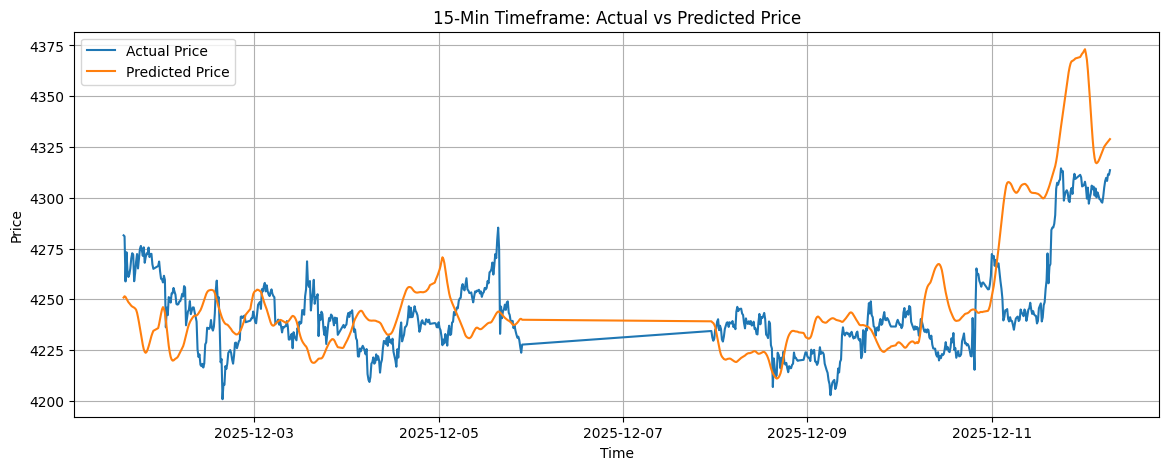

In [ ]:
import matplotlib.pyplot as plt

# ================= 15 MIN ACTUAL vs PREDICTED (FIXED) =================
pred_15 = []
actual_15 = []
time_15 = []

for i in range(LOOKBACK, len(X15)):
    p = model15.predict(X15[i].reshape(1, LOOKBACK, 1), verbose=0)[0][0]
    p_price = sc15.inverse_transform([[p]])[0][0]

    pred_15.append(p_price)
    actual_15.append(df["Close"].iloc[i])
    time_15.append(df.index[i])

plt.figure(figsize=(14,5))
plt.plot(time_15, actual_15, label="Actual Price")
plt.plot(time_15, pred_15, label="Predicted Price")
plt.title("15-Min Timeframe: Actual vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()



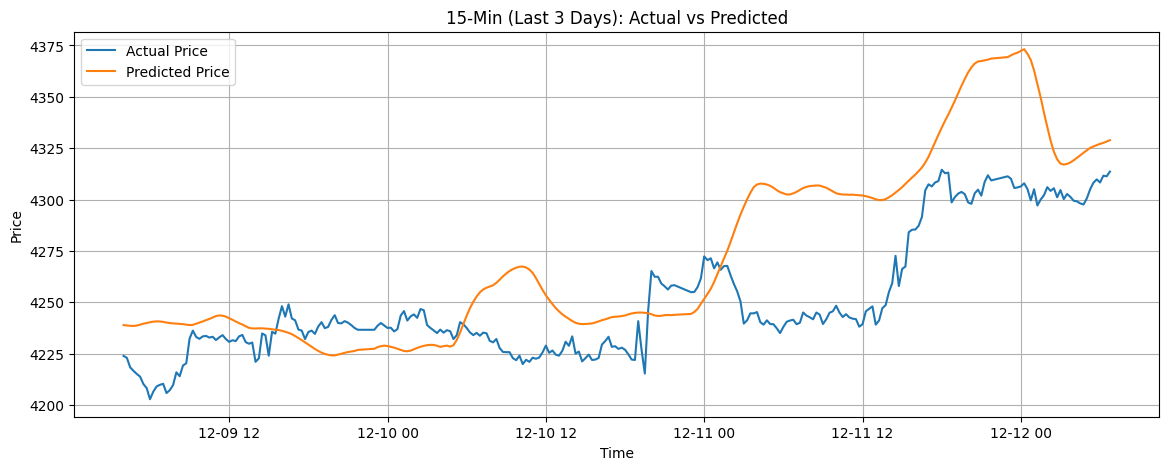

In [ ]:
# ================= LAST 3 DAYS ZOOM =================
bars_3d = 3 * 24 * 4  # 3 days of 15m candles

plt.figure(figsize=(14,5))
plt.plot(time_15[-bars_3d:], actual_15[-bars_3d:], label="Actual Price")
plt.plot(time_15[-bars_3d:], pred_15[-bars_3d:], label="Predicted Price")
plt.title("15-Min (Last 3 Days): Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
import numpy as np
import pandas as pd

# ---------------- BASIC COUNTS ----------------
total_trades = len(trade_df)
wins = trade_df[trade_df["Profit"] > 0]
losses = trade_df[trade_df["Profit"] < 0]

win_trades = len(wins)
loss_trades = len(losses)

gross_profit = wins["Profit"].sum()
gross_loss = losses["Profit"].sum()
net_profit = trade_df["Profit"].sum()

win_rate = win_trades / total_trades * 100 if total_trades else 0
profit_factor = gross_profit / abs(gross_loss) if gross_loss != 0 else np.inf

# ---------------- LONG / SHORT ----------------
longs = trade_df[trade_df["Type"] == "buy"]
shorts = trade_df[trade_df["Type"] == "sell"]

long_win = len(longs[longs["Profit"] > 0])
short_win = len(shorts[shorts["Profit"] > 0])

# ---------------- AVERAGES ----------------
avg_profit_trade = wins["Profit"].mean() if win_trades else 0
avg_loss_trade = losses["Profit"].mean() if loss_trades else 0

largest_profit = wins["Profit"].max() if win_trades else 0
largest_loss = losses["Profit"].min() if loss_trades else 0

# ---------------- EQUITY & DRAWDOWN ----------------
equity = trade_df["Profit"].cumsum()
peak = equity.cummax()
drawdown = peak - equity

max_drawdown = drawdown.max()
dd_relative = (max_drawdown / peak.max()) * 100 if peak.max() != 0 else 0
dd_absolute = drawdown.iloc[-1]

# ---------------- CONSECUTIVE WINS / LOSSES ----------------
def streaks(profits, win=True):
    arr = (profits > 0).astype(int) if win else (profits < 0).astype(int)
    max_streak = cur = 0
    for x in arr:
        cur = cur + 1 if x else 0
        max_streak = max(max_streak, cur)
    return max_streak

max_consec_wins = streaks(trade_df["Profit"], win=True)
max_consec_losses = streaks(trade_df["Profit"], win=False)

avg_consec_wins = win_trades / max_consec_wins if max_consec_wins else 0
avg_consec_losses = loss_trades / max_consec_losses if max_consec_losses else 0

max_consec_profit = equity.diff().rolling(max_consec_wins).sum().max()

# ---------------- SHARPE (SIMPLE) ----------------
returns = trade_df["Profit"]
sharpe = returns.mean() / returns.std() if returns.std() != 0 else 0

# ---------------- RECOVERY FACTOR ----------------
recovery_factor = net_profit / max_drawdown if max_drawdown != 0 else np.inf

# ================= PERFORMANCE TABLE =================
performance_summary = pd.DataFrame({
    "Key metrics": [
        "Total Net Profit",
        "Profit Factor",
        "Total Trades",
        "Recovery Factor",
        "Short Trades (won %)",
        "Largest Profit Trade",
        "Long Trades (won %)",
        "Largest Loss Trade",
        "Win Trades (% of total)",
        "Average Profit Trade",
        "Loss Trades (% of total)",
        "Average Loss Trade",
        "Balance Drawdown Maximal",
        "Max Consecutive Wins",
        "Balance Drawdown Relative",
        "Max Consecutive Losses",
        "Balance Drawdown Absolute",
        "Avg Consecutive Wins",
        "Max Consecutive Profit",
        "Avg Consecutive Losses",
        "Max Drawdown",
        "Sharpe Ratio"
    ],
    "Performance analysis": [
        f"${net_profit:,.2f}",
        round(profit_factor, 2),
        total_trades,
        round(recovery_factor, 2),
        f"{short_win}/{len(shorts)} ({short_win/len(shorts)*100:.2f}%)" if len(shorts) else "0",
        round(largest_profit, 2),
        f"{long_win}/{len(longs)} ({long_win/len(longs)*100:.2f}%)" if len(longs) else "0",
        round(largest_loss, 2),
        f"{win_trades}/{total_trades} ({win_rate:.2f}%)",
        f"${avg_profit_trade:.2f}",
        f"{loss_trades}/{total_trades} ({100-win_rate:.2f}%)",
        f"({avg_loss_trade:.2f})",
        f"${max_drawdown:.2f}",
        f"{max_consec_wins}",
        f"{dd_relative:.2f}%",
        f"{max_consec_losses}",
        f"${dd_absolute:.2f}",
        round(avg_consec_wins, 2),
        f"${max_consec_profit:.2f} ({max_consec_wins})",
        round(avg_consec_losses, 2),
        f"${max_drawdown:.2f}",
        round(sharpe, 2)
    ]
})

display(performance_summary)


,Key metrics,Performance analysis
0,Total Net Profit,"$1,570.70"
1,Profit Factor,1.31
2,Total Trades,382
3,Recovery Factor,2.15
4,Short Trades (won %),187/382 (48.95%)
5,Largest Profit Trade,1021.2
6,Long Trades (won %),0
7,Largest Loss Trade,-342.0
8,Win Trades (% of total),187/382 (48.95%)
9,Average Profit Trade,$35.32


In [ ]:
# ================= SESSION WISE =================
trade_df["Hour"] = trade_df["Time"].dt.hour

def session(hour):
    if 0 <= hour < 8:
        return "Asian"
    elif 8 <= hour < 16:
        return "London"
    else:
        return "New York"

trade_df["Session"] = trade_df["Hour"].apply(session)

session_stats = trade_df.groupby("Session").agg(
    Trades=("Profit","count"),
    Wins=("Profit",lambda x: (x>0).sum()),
    Losses=("Profit",lambda x: (x<0).sum()),
    Net_Profit=("Profit","sum"),
    Avg_Profit=("Profit","mean"),
    Win_Rate=("Profit",lambda x: (x>0).mean()*100)
).round(2)

display(session_stats)


,Trades,Wins,Losses,Net_Profit,Avg_Profit,Win_Rate
Session,,,,,,
Asian,128,61,67,287.5,2.25,47.66
London,125,62,61,1158.6,9.27,49.60
New York,129,64,63,124.6,0.97,49.61
